---
title: "Introducing Seaborn"
subtitle: "DS 2023 | Communicating with Data"
---

<img src="https://seaborn.pydata.org/_static/logo-wide-lightbg.svg"/>

## Overview

Seaborn is visualization library written in Python and built on top of Matplotlib.

According to [its website](https://seaborn.pydata.org/), Seaborn "provides a high-level interface for drawing attractive and informative statistical graphics."


Seaborn provides **three programming interfaces** for creating visualizations:

**Axes-Level Functions**:

- Functions include `sns.barplot()`, `sns.scatterplot()`, `sns.histplot()`, `sns.boxplot()`, etc.
- These plot data onto a single Matplotlib Axes object and return that Axes.
- They integrate smoothly into pre-existing multi-panel Matplotlib figures.
- Many of these functions are drop-in replacements for Pandas' plot types.
   
**Figure-Level Functions**: 

- Functions include `sns.relplot()`, `sns.displot()`, and `sns.catplot()`.
- These three functions group together the Axes plot types into Figure level functions.
- They manage an entire figure using a Seaborn container object (usually a `FacetGrid`).
- They easily generate multi-plot grids (small multiples) and control layout properties like legend placement at the figure level.
   
**The Object-Oriented Interface**: 

- A modular system is inspired by the Grammar of Graphics.
- It initializes with the `so.Plot()` constructor and builds graphics incrementally.
- Variables are mapped to visual Mark layers (e.g., `so.Dot()`, `so.Bar()`).

**Pandas vs. Seaborn Interfaces Mapping Table**

| Plot Type | Pandas  | Seaborn Axes | Seaborn Figure | Seaborn Object |
|---|---|---|---|---|
| Scatter Plot | `df.plot.scatter()` | `sns.scatterplot()` | `sns.relplot(kind="scatter")` | `so.Plot().add(so.Dot())` |
| Line Plot | `df.plot.line()` | `sns.lineplot()` | `sns.relplot(kind="line")` | `so.Plot().add(so.Line())` |
| Histogram | `df.plot.hist()` | `sns.histplot()` | `sns.displot(kind="hist")` | `so.Plot().add(so.Bar(), so.Hist())` |
| KDE Plot | `df.plot.kde()` | `sns.kdeplot()` | `sns.displot(kind="kde")` | `so.Plot().add(so.Line(), so.KDE())` |
| Box Plot | `df.plot.box()` | `sns.boxplot()` | `sns.catplot(kind="box")` | `so.Plot().add(so.Box())` |
| Bar Plot | `df.plot.bar()`| `sns.barplot()`<br/>`sns.countplot()` | `sns.catplot(kind="bar")` <br/>`sns.catplot(kind="count")`| `so.Plot().add(so.Bar())` |

## Seaborn's design philosophy

Seaborn is an opiniated graphics library.

It is designed to produce statistical plots from Tidy data as efficiently and as clearly as possible.

To do this, it shields the user from many of the data transformations that we have learned, like creating wide-form data and applying aggregate functions.

> [!IMPORTANT]
>
> Shielding the user from lower-level data functions is an example of **abstraction** in programming language design.
>
> Abstraction **simplifies many tasks**, but it comes at a **cost**: the user loses touch with the **logic** of what they are doing.
> 
> Additionally, abstractions are **rarely complete** &mdash; they tend to have gaps that require the user to go back to the level they are being shielded from.
> 
> In most cases, however, this is **an acceptable and, indeed, necessary trade-off**, as when early programming languages like FORTRAN abstracted assembler code into functions.


## Axes level functions

In this notebook, we will focus on Seaborn's **Axes level functions**.

These are, for the most part, drop-in replacements for the same functions in Pandas and Matplotlib.

### Bar plots

Let's begin with bar plots, using the Penguins dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset('penguins').dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


To create a bar plot showing the counts of a category variable, we can first compute the `value_counts` and then plot them directly.

In [3]:
penguins.species.value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

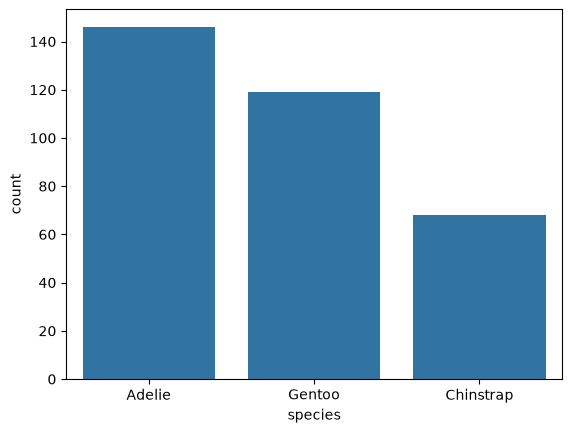

In [4]:
sns.barplot(penguins.species.value_counts())
plt.show()

> [!NOTE]
>
> Unlike Pandas, which wraps Matplotlib plotting functions as dataframe methods, in Seaborn, the dataframe is passed as an argument to the plotting function.
>
> The dataframe can be the first argument to the function, or it can be passed as a value to the `data` parameter, e.g. `sns.barplot(data=df, ...)`.

**Count plots**

Plots that show counts like this are so common that Seaborn provides a dedicated function for it called `countplot`.

The `countplot` function automatically does the value counting for you.

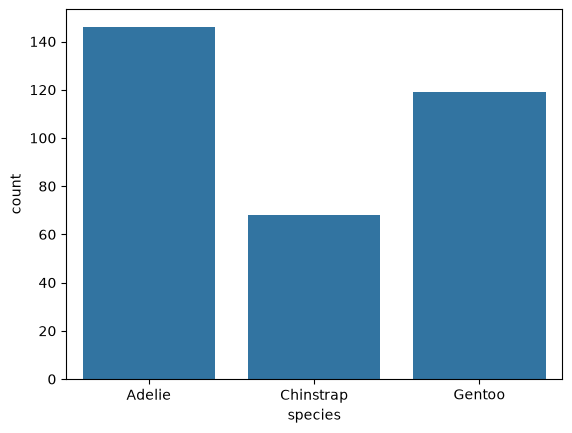

In [5]:
sns.countplot(penguins, x='species')
plt.show()

Note the change in sort order of the category names, though. 

It defaults to alphabetical order.

To change the order, you have to set the `order` parameter yourself, like so:

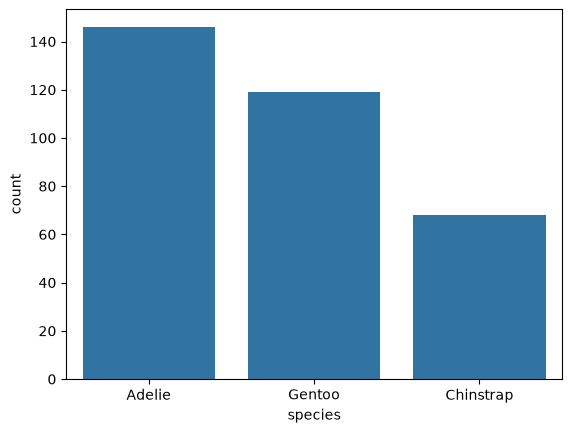

In [6]:
my_order = penguins['species'].value_counts().index
sns.countplot(penguins, x='species', order=my_order)
plt.show()

Notice how this breaks Seaborn's principle of abstracting low-level data operations from the user.

**Back to bar plots**

Seaborn will also plot bars for any measurement variable against a grouping variable.

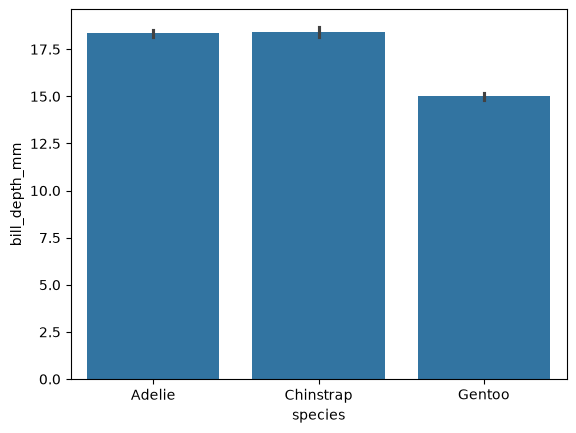

In [7]:
sns.barplot(penguins, x='species', y='bill_depth_mm')
plt.show()

In creating this plot, Seaborn assumes you want to aggregate the value of the measurement variable against the grouping one.

By default, it computes the mean.

> [!NOTE]
>
> Notice the little vertical lines at the top of each bar.
>
> These are error bars (even though they are lines).
>
> They show error measures like confidence intervals, which are represented by default.
>
> Seaborn computes these behind the scenes using a statistical method called **bootstrapping**.

You can change the aggregation function using the `estimator` parameter to `median`, `std`, `sum`, etc.

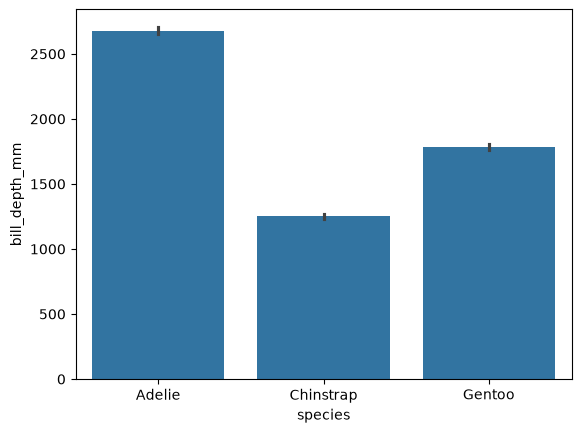

In [8]:
sns.barplot(penguins, x='species', y='bill_depth_mm', estimator='sum')
plt.show()

If you don't want to have the error calculated and show the bars, set `errorbar=None`.

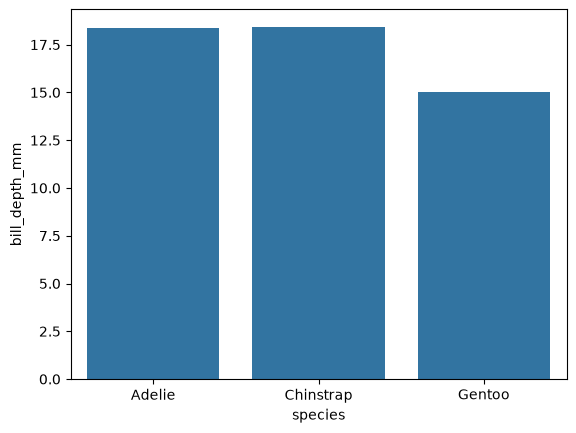

In [9]:
sns.barplot(penguins, x='species', y='bill_depth_mm', errorbar=None)
plt.show()

**Two grouping variables**

To show a second grouping variable, just set `hue` to that variable.

Seaborn handles the data transformation for you.

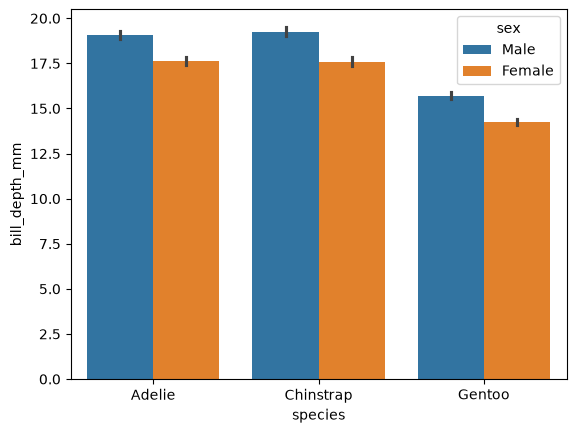

In [10]:
sns.barplot(penguins, x='species', y='bill_depth_mm', hue='sex')
plt.show()

You can use `hue` on count plots, too.

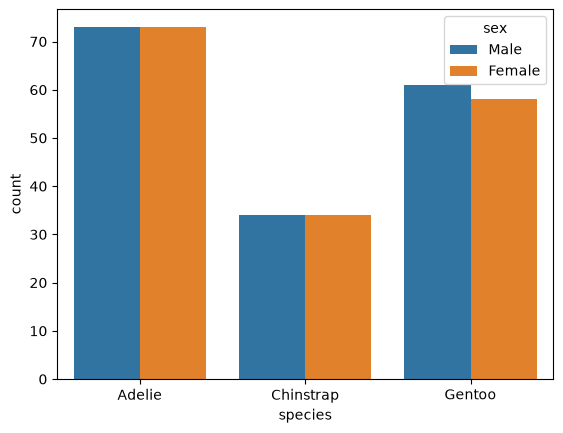

In [11]:
sns.countplot(penguins, x='species', hue='sex')
plt.show()

### Pie charts

Seaborn doesn't do pie charts.

### Line plots

To create a line plot, you pass series data to the x and y parameters. 

In [12]:
dowjones = sns.load_dataset('dowjones')
dowjones.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


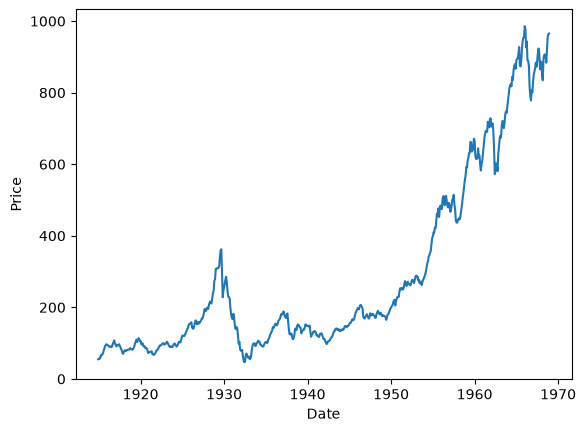

In [13]:
sns.lineplot(dowjones, x='Date', y='Price')
plt.show()

**Using series or wide-form data**

You can also pass a standalone Pandas series or a wide-form dataframe to a Seaborn Axes function.

In these cases, you don't have to define explicit x or y variables.

Seaborn will default to using the index values as the x axis and the series columns for the y axis.

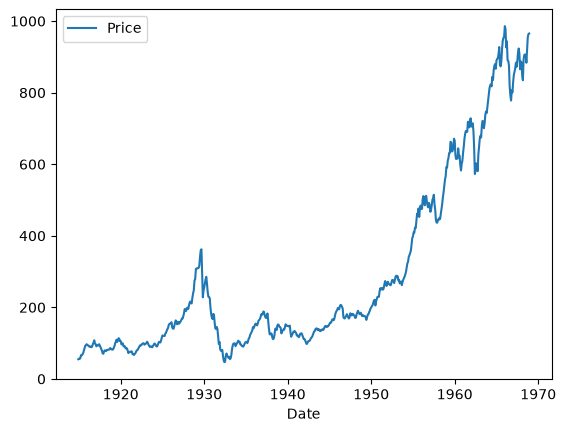

In [14]:
dowjones1 = dowjones.set_index('Date')
sns.lineplot(dowjones1)
plt.show()

**Changing figure size**

If you want to change the size of a Seaborn Axes level plot, you have to use Matplotlib.

This is true of all Axes level functions.

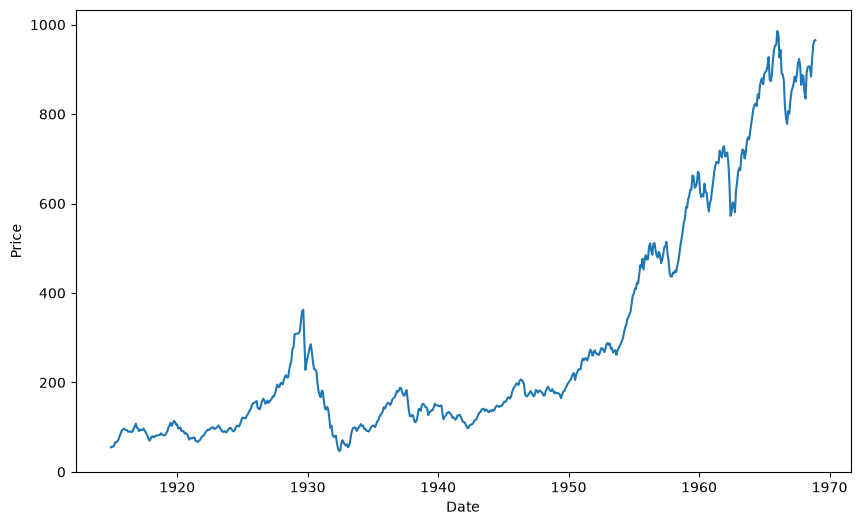

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(dowjones, x='Date', y='Price', ax=ax)
plt.show()

**Using a grouping variable**

Let's look at an example where there is a grouping variable.

In [16]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


Here, we plot the data without specifying the grouping variable `month`, even though without it, the `years` variable is repeated.

In this case, the line plot defaults to aggregating the observations that belong to the `month` variable.

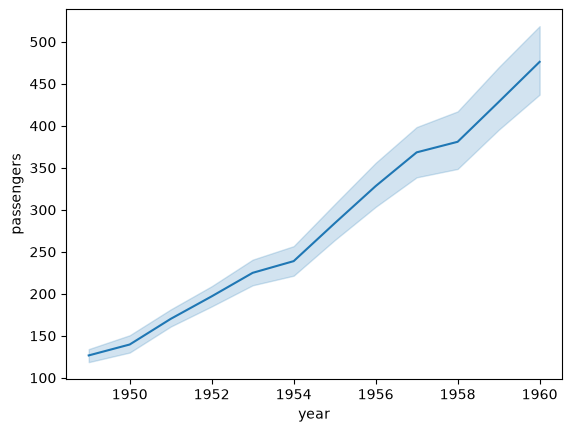

In [17]:
sns.lineplot(flights, x='year', y='passengers')
plt.show()

The shaded area represents the 95% confidence interval for the mean number of passengers spending across months in the dataset for a given year.

To show standard deviation instead of the confidence interval, change the value of `errorbar` to `sd`.

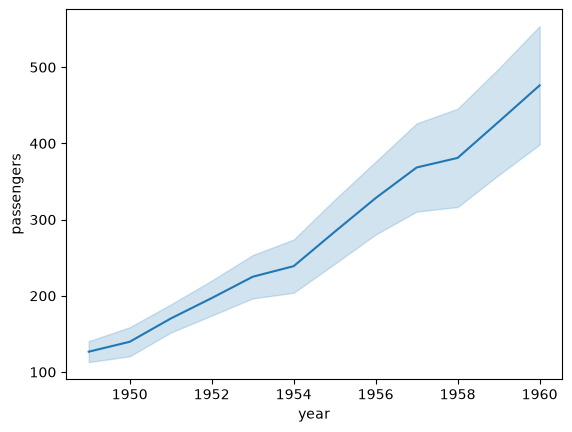

In [18]:
sns.lineplot(flights, x='year', y='passengers', errorbar='sd')
plt.show()

Or, to lose the representation of error altogether, do this:

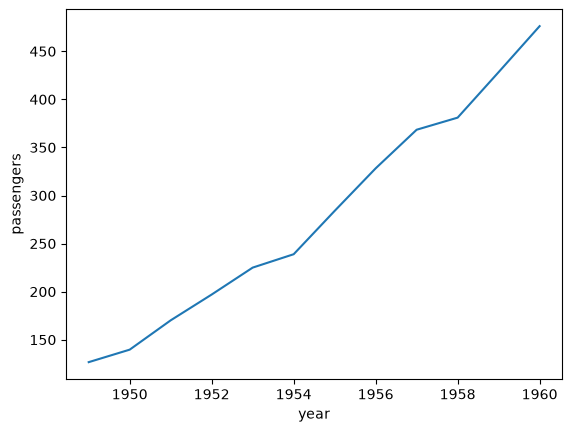

In [19]:
sns.lineplot(flights, x='year', y='passengers', errorbar=None)
plt.show()

To bypass aggregation and actually show lines for each value of the grouping variable `month`, we set `hue` to that variable.

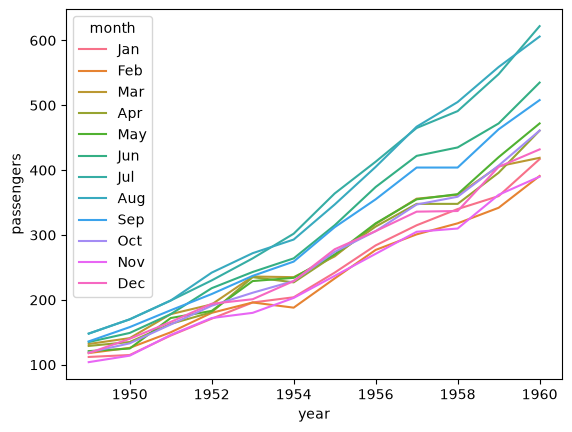

In [20]:
sns.lineplot(flights, x='year', y='passengers', hue='month')
plt.show()

A more interesting plot in this case would be to set the `hue` to `year` and `x` to `month`.

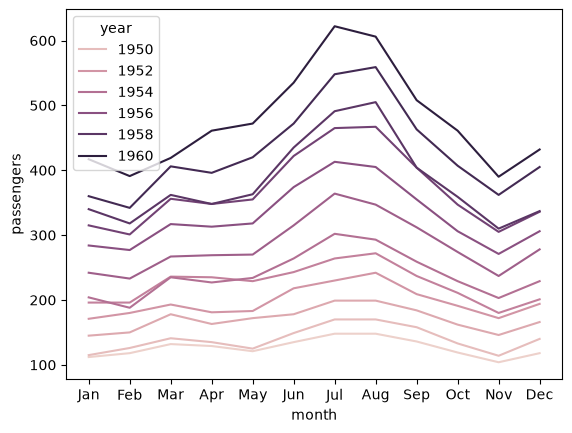

In [21]:
sns.lineplot(flights, x='month', y='passengers', hue='year')
plt.show()

> [!IMPORTANT]
>
> The `hue` parameter does a lot of work behind the scenes.
>
> It takes the argument variable and groups the tidy dataframe by it, and then maps the subgroups to individual plots.
>
> This is equivalent to creating a wide-form dataframe for you.


Notice that although Seaborn expects tidy data, you can also pass it a wide dataframe and it will (usually) know what to do.

In [22]:
flights_wide = flights.pivot(index='month', columns='year', values='passengers')
flights_wide.head()

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472


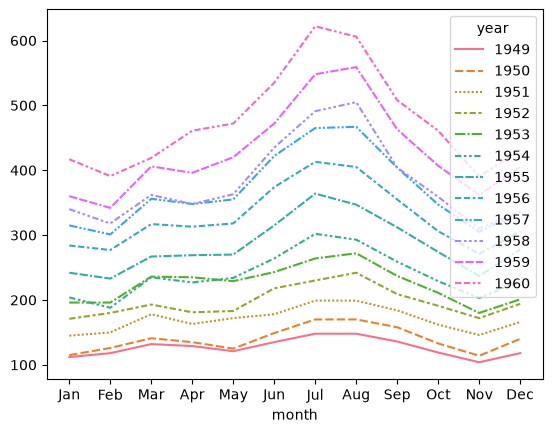

In [23]:
sns.lineplot(flights_wide)
plt.show()

> [!NOTE]
>
> Notice the subtle differences in design decisions made in the two cases.
>
> In the first case, the values were interpreted as continuous numbers.
>
> In the second, they are interpreted as discrete categories.

### Area charts


There are no area charts in Seaborn.

If you want them, you can fall back on Matplotlib's `fill_between` since we are working with Seaborn's Axes level functions.

Here is a worked out example.

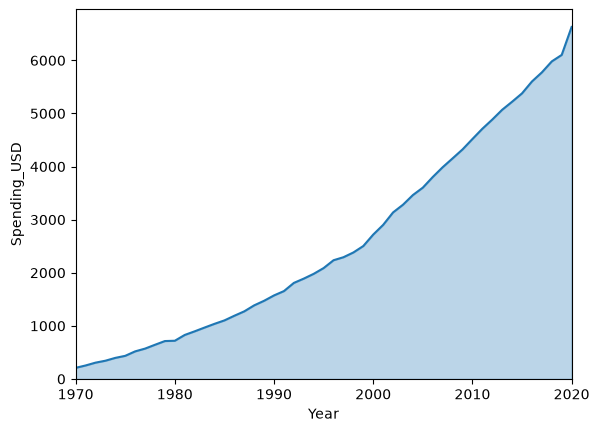

In [24]:
healthexp = sns.load_dataset('healthexp')

ax = sns.lineplot(data=healthexp, x='Year', y='Spending_USD', errorbar=None)

# You have to use Matplotlib to grab the line first
line = ax.lines[0]
x = line.get_xdata()
y = line.get_ydata()

ax.fill_between(x, y, color=line.get_color(), alpha=0.3)
# ax.fill_between(x, y, 0, color=line.get_color(), alpha=0.3) # Same

ax.set_xlim(1970, 2020)
ax.set_ylim(0, None)

plt.show()

> [!NOTE]
>
> As evidence for how opinioniated Seaborn is, its creator has [explicitly declined requests](https://github.com/mwaskom/seaborn/issues/2410) to add a fill parameter to `sns.lineplot()`.
>
> The library reserves translucent shading strictly for showing statistical uncertainty.
>
> It avoids using fill to represent the baseline quantity itself.

### Scatter plots


Let's map two measurement variables to the x and y axes, and then use `hue` to represent the grouping variable `species`.

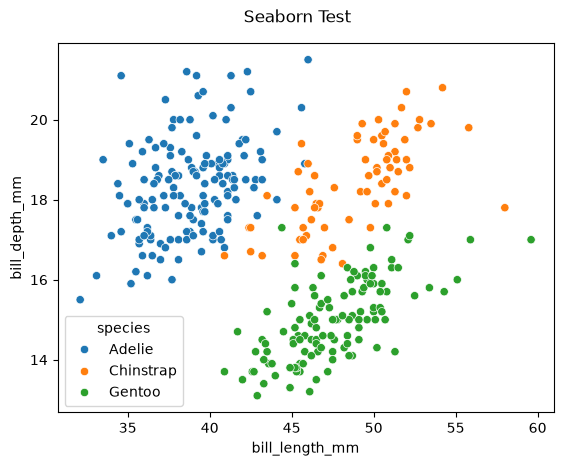

In [25]:
sns.scatterplot(penguins, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.suptitle("Seaborn Test", y=.95)
plt.show()

Here, we map `body_mass_g` to the point size with `size`.

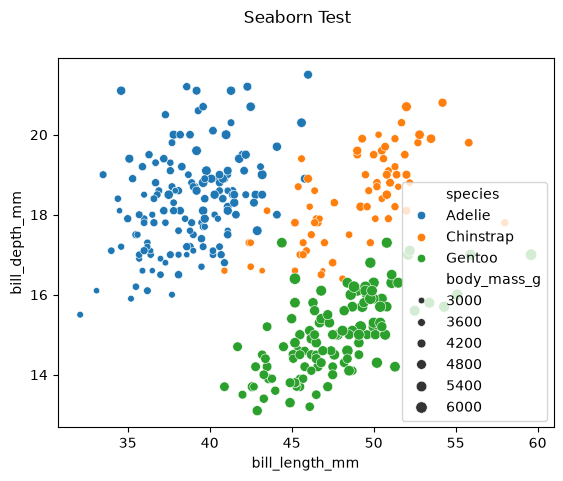

In [26]:
sns.scatterplot(penguins,
                x='bill_length_mm',
                y='bill_depth_mm',
                hue='species',
                size='body_mass_g')
plt.suptitle("Seaborn Test")
plt.show()

We move the legend to the side so we can see our data points better.

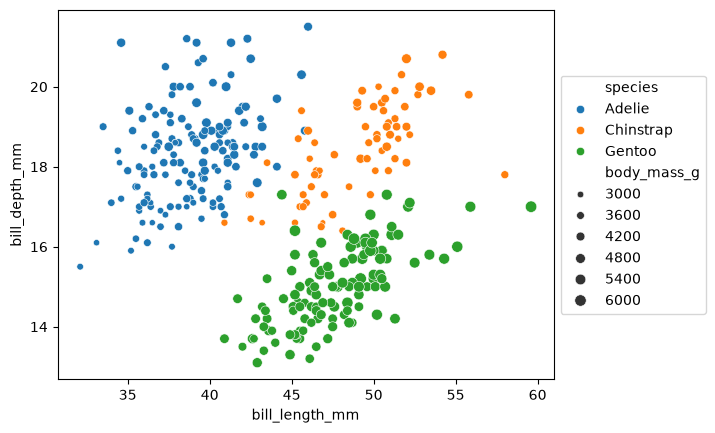

In [27]:
sns.scatterplot(penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    size='body_mass_g'
)
plt.legend(loc='center left', bbox_to_anchor=(1, .5))
plt.show()

Now let's add `island` as shape with `style`.

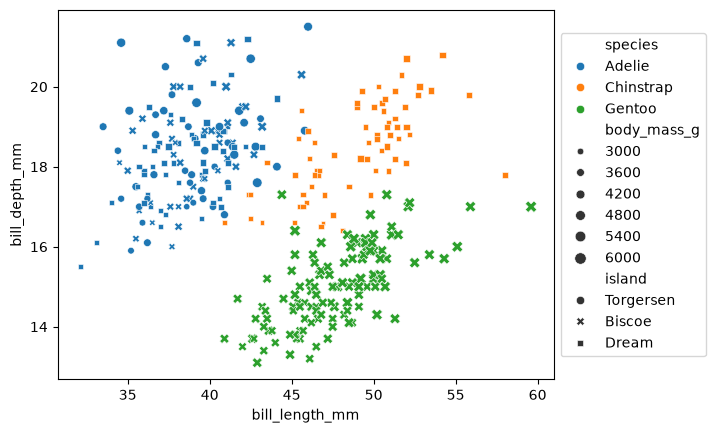

In [28]:
sns.scatterplot(penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    size='body_mass_g',
    style='island'
)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

Looks like most of the Gentoos are on Biscoe and most of the Chinstraps are on Dream.

The Adelies are on all the islands.

This was seen in our original tabular visualization.

In [29]:
penguins.value_counts(['species', 'island']).unstack(fill_value=0).style.background_gradient(cmap='Blues', axis=None)

island,Torgersen,Biscoe,Dream
species,,,
Adelie,47,44,55
Chinstrap,0,0,68
Gentoo,0,119,0


### Regression plots

Seaborn also include a regression plot in its collection of Axes level function.

Here we draw a line for the population as a whole.

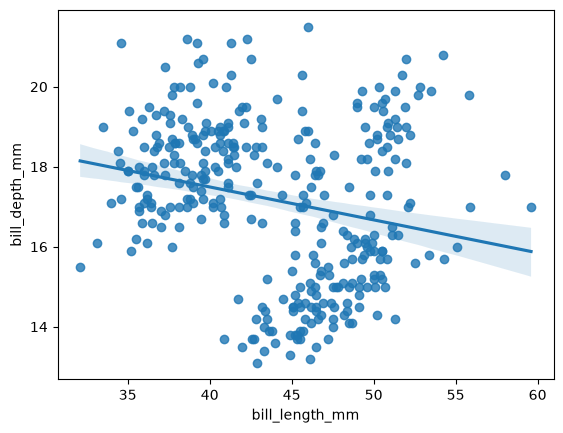

In [30]:
sns.regplot(penguins,  x='bill_length_mm', y='bill_depth_mm')
plt.show()

To show regression lines by species, we resort to creating subplots for individual groups.

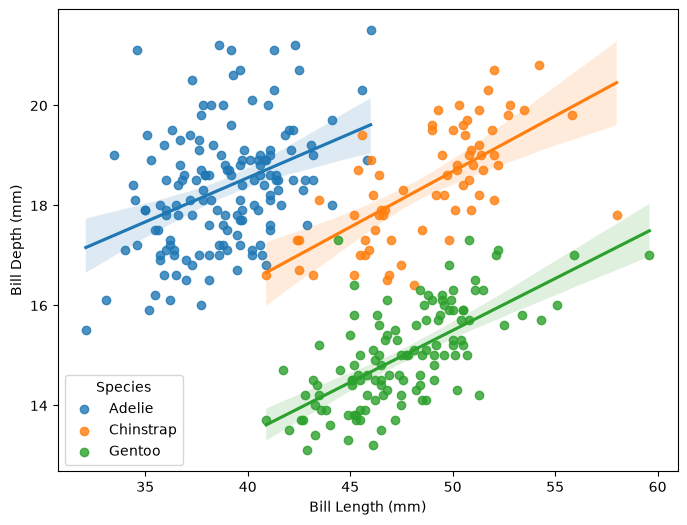

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

for species, subset in penguins.groupby('species'):
    sns.regplot(subset, x="bill_length_mm", y="bill_depth_mm", ax=ax, label=species)

ax.set_xlabel("Bill Length (mm)")
ax.set_ylabel("Bill Depth (mm)")
ax.legend(title="Species")

plt.show()

And here is one way to show both the group level and overall regression lines.

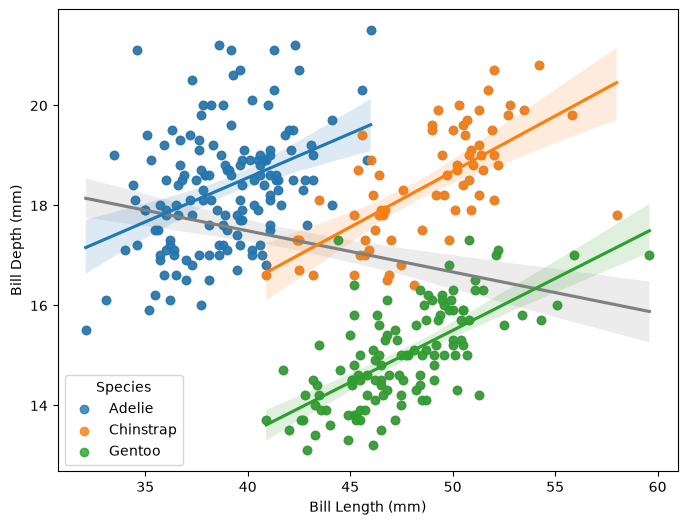

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(penguins,  x='bill_length_mm', y='bill_depth_mm', ax=ax, color='gray')

for species, subset in penguins.groupby('species'):
    sns.regplot(subset, x="bill_length_mm", y="bill_depth_mm", ax=ax, label=species)

ax.set_xlabel("Bill Length (mm)")
ax.set_ylabel("Bill Depth (mm)")
ax.legend(title="Species")

plt.show()

> [!NOTE]
>
> The above plot is an example of Simpson's paradox.
>
> This happens when population and subpopulation regression lines go in opposite directions.

### Histograms

Of course, Seaborn does histograms.

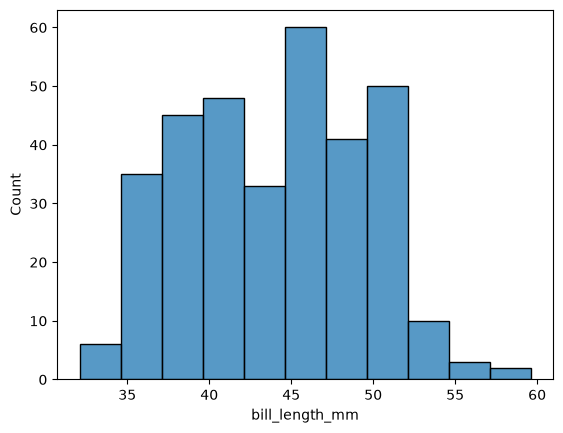

In [33]:
sns.histplot(penguins, x='bill_length_mm')
plt.show()

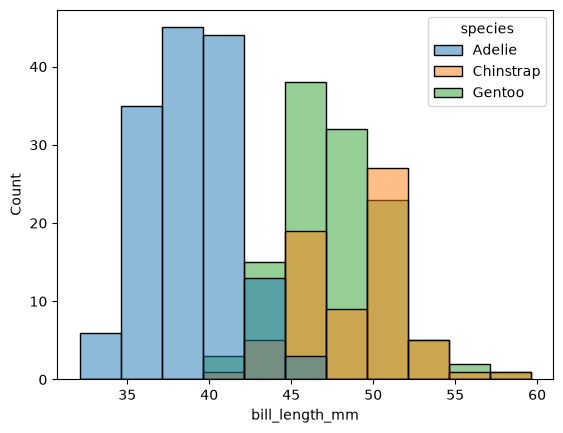

In [34]:
sns.histplot(penguins, x='bill_length_mm', hue='species')
plt.show()

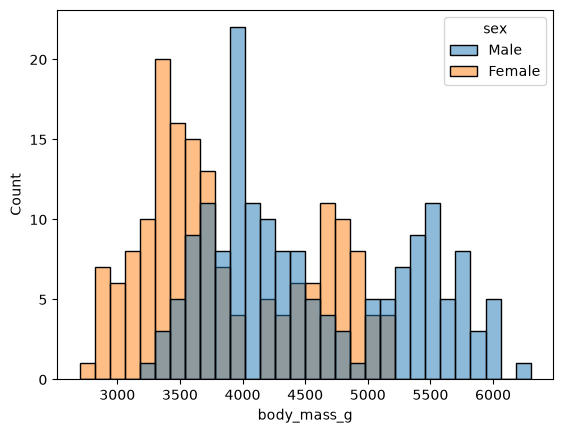

In [35]:
sns.histplot(penguins, x='body_mass_g', hue='sex', bins=30)
plt.show()

### KDE plots

Seaborn also does KDE plots.

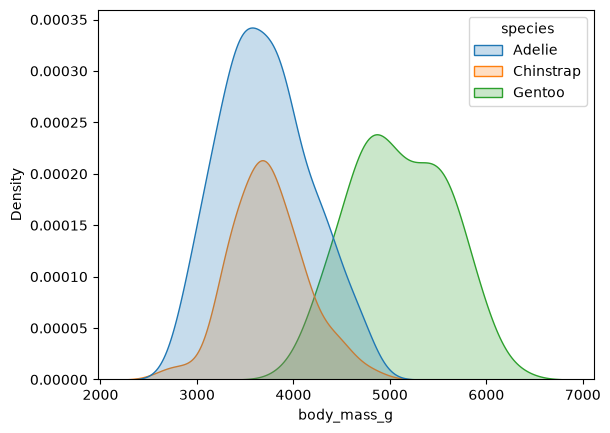

In [36]:
sns.kdeplot(penguins, x='body_mass_g', hue='species', fill=True)
plt.show()

KDE plots can plot two series on the x and y axes to produce this effect.

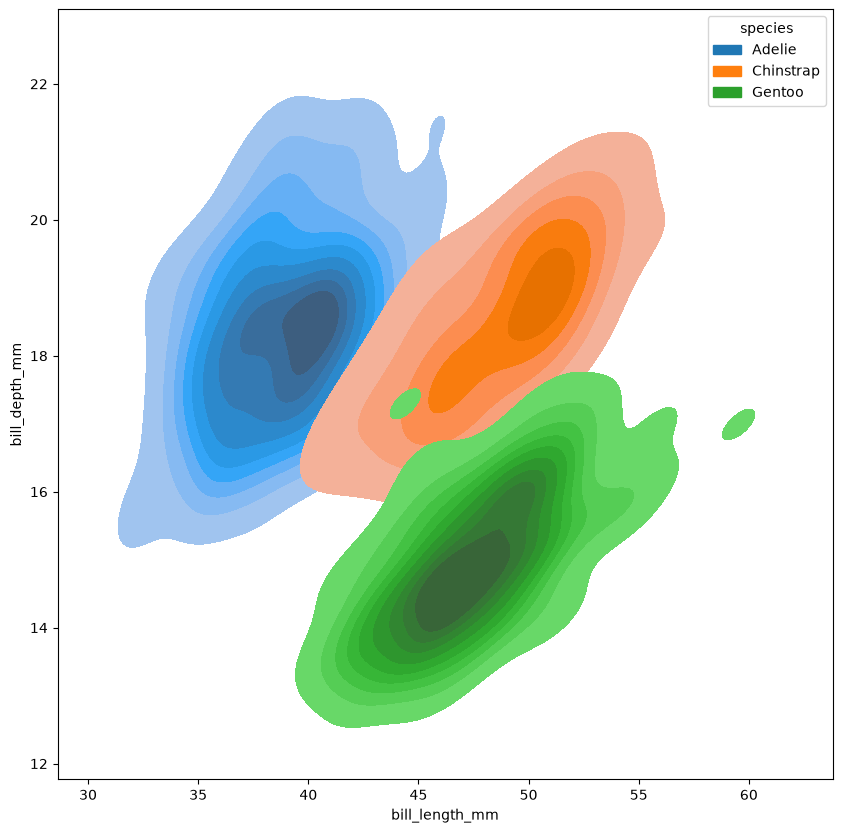

In [37]:
fig, ax = plt.subplots(figsize=(10,10))
sns.kdeplot(penguins, x='bill_length_mm', y='bill_depth_mm', hue='species', fill=True, ax=ax)
plt.show()

### Box plots

Seaborn does box plots, which are colored-in by default.

Passing the whole dataframe creates this plot, which is not very useful since the domains of each measure are different.

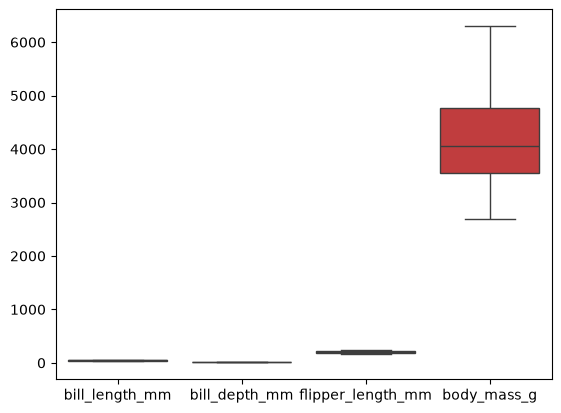

In [38]:
sns.boxplot(penguins)
plt.show()

Here is a single variable plotted.

Note the overly wide formatting by default.

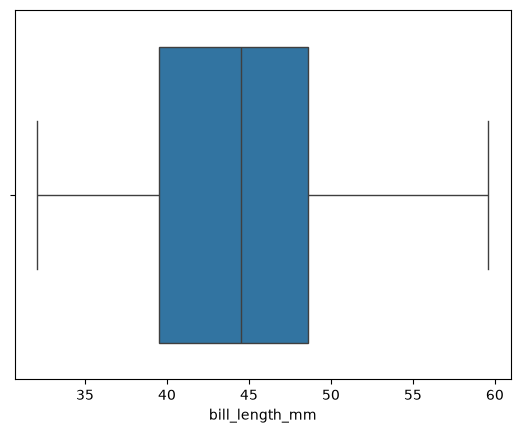

In [39]:
sns.boxplot(penguins, x='bill_length_mm')
plt.show()

Adding a variable to `hue` creates a nice set of paired box plots.

This is actually hard to do in Pandas.

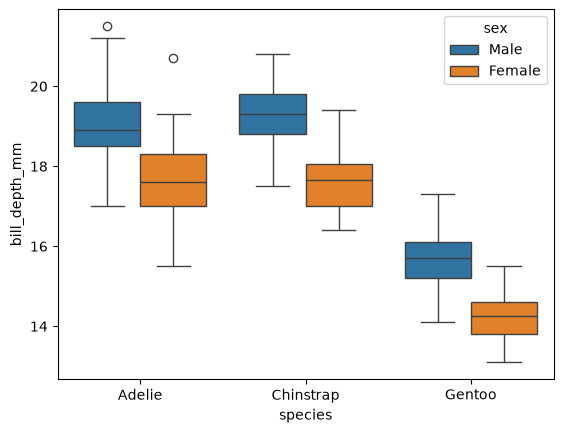

In [40]:
sns.boxplot(penguins, x='species', y='bill_depth_mm', hue='sex')
plt.show()

### Subplots

To create subplots with Seaborn's Axes level function, you use Matplotlib's subplot functions, e.g.

```python
fig, ax = plt.subplots(2, 1, figsize=(5, 10))
```

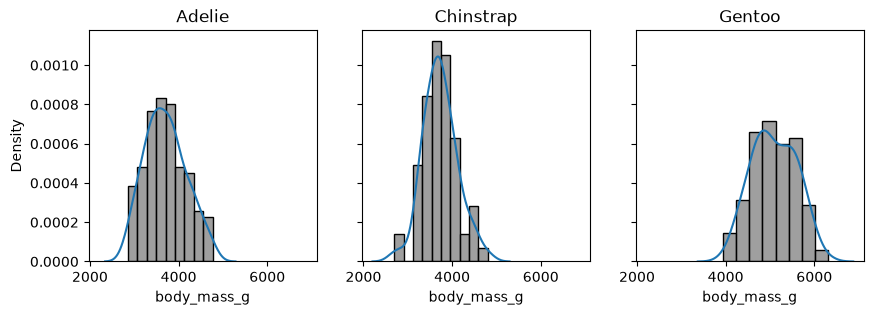

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharey=True, sharex=True)

for i, group in enumerate(penguins.groupby('species')):
    species, subset = group
    sns.histplot(subset, x='body_mass_g', ax=ax[i], stat='density', color='tab:gray')
    sns.kdeplot(subset, x='body_mass_g', ax=ax[i])
    ax[i].set_title(species)

plt.show()

## Joint PLots

Seaborn offers some useful combination plots called Joint Plots.

These are not Axes level functions, however, and so can't be manipulated by Matplotlib functions in the usual way.

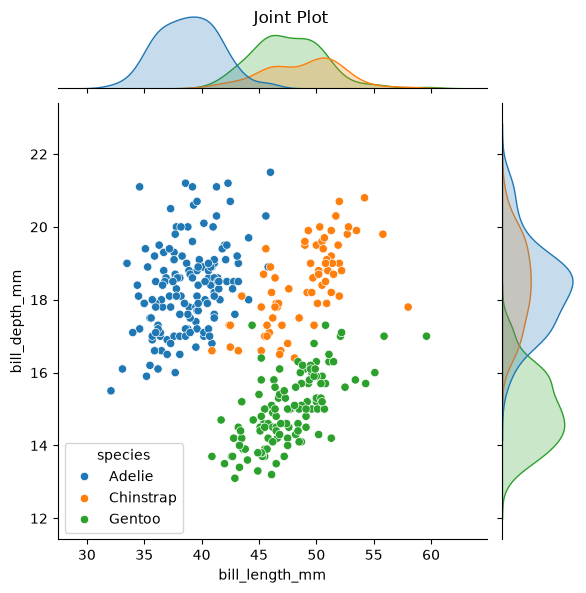

In [42]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue='species', kind="scatter")
plt.suptitle("Joint Plot")
plt.show()

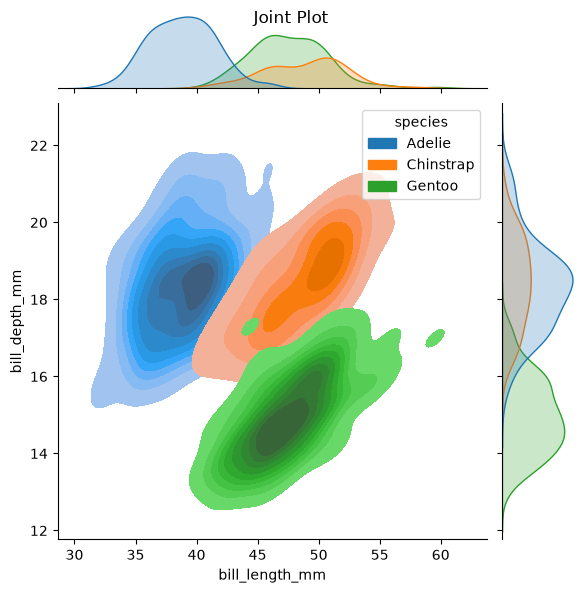

In [43]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue='species', kind="kde", fill=True)
plt.suptitle("Joint Plot")
plt.show()

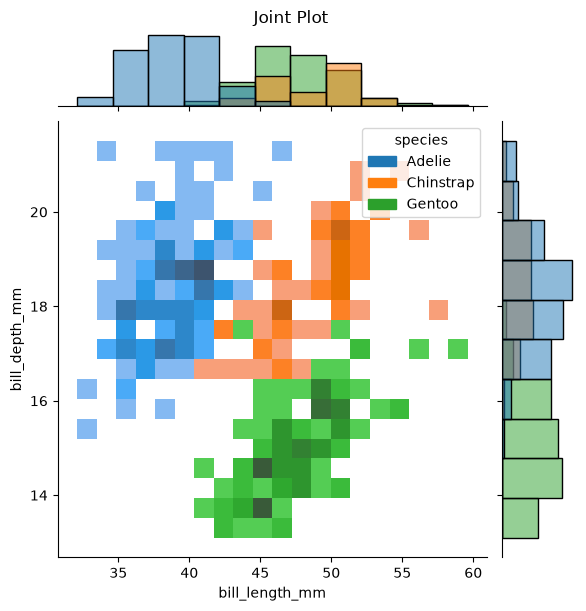

In [44]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue='species', kind="hist", bins=20)
plt.suptitle("Joint Plot", y=1.01)
plt.show()